# Loss studies: compare a replica's loss across fits

Loads **three fits**, picks **one replica**, and overlays that replica's
**training (solid)** and **validation (dashed)** loss curves across the three
fits in a single figure (one colour per fit).

The losses are the *recomputed* ones from `loss_function_grid` (the same
quantity the report's loss page uses): for each stored epoch it rebuilds the
model, predicts the PDF and evaluates the train/val loss through the FK/Cinv
chain. That prediction runs at **every** epoch, so set `CUSTOM_EPOCHS` to a
handful of epochs (each must have saved weights) to keep it fast.

In [5]:
%matplotlib inline
from IPython.display import display

# Importing the API first sets KERAS_BACKEND=jax (via ntkpdf/__init__.py).
from ntkpdf.api import API
from ntkpdf.plotting.style import make_figure, draw_line, HandlerSpec, LineHandler, OKABE_ITO

import logging
logging.basicConfig(level=logging.INFO)

In [6]:
# --- Edit these ---------------------------------------------------------
FITS = [
    "260611-ac-03-ntk-sgd", # gamma = 0.001
    "260611-ac-01-ntk-sgd", # gamma = 1
    "260622-ac-01-ntk-sgd", # gamma = 2
    "260611-ac-02-ntk-sgd", # gamma = 3
    "260622-ac-02-ntk-sgd", # gamma = 4
    "260622-ac-03-ntk-sgd", # gamma = 5
    # "260622-ac-03-ntk-sgd-long", # gamma = 5
]
LABELS = [
          r"$\rm \gamma = 0.001$", 
          r"$\rm \gamma = 1$", 
          r"$\rm \gamma = 2$", 
          r"$\rm \gamma = 3$", 
          r"$\rm \gamma = 4$", 
          r"$\rm \gamma = 5$",
          # r"$\rm \gamma = 5$ (long)",
          ]
REPLICA = 3                          # 1-based replica id to compare
CUSTOM_EPOCHS = None
YSCALE = "log"
XSCALE = "linear"
# ------------------------------------------------------------------------

# Minimal data/theory context the FK chain behind loss_function_grid needs.
common_dict = dict(
    dataset_inputs={"from_": "fit"},
    use_cuts="fromfit",
    theory={"from_": "fit"},
    theoryid={"from_": "theory"},
)

In [7]:
# Build the (training, validation) loss grids for each fit.
grids = {
    fit: API.loss_function_grid(fit=fit, **common_dict, custom_epochs=CUSTOM_EPOCHS)
    for fit in FITS
}

/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'NN_input': 'NN_input'}
Received: inputs=Tensor(shape=(1, 50, 2))
  warnings.warn(msg)


/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'NN_input': 'NN_input'}
Received: inputs=Tensor(shape=(1, 50, 2))
  warnings.warn(msg)


/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'NN_input': 'NN_input'}
Received: inputs=Tensor(shape=(1, 50, 2))
  warnings.warn(msg)


/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'NN_input': 'NN_input'}
Received: inputs=Tensor(shape=(1, 50, 2))
  warnings.warn(msg)


/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'NN_input': 'NN_input'}
Received: inputs=Tensor(shape=(1, 50, 2))
  warnings.warn(msg)


/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'NN_input': 'NN_input'}
Received: inputs=Tensor(shape=(1, 50, 2))
  warnings.warn(msg)


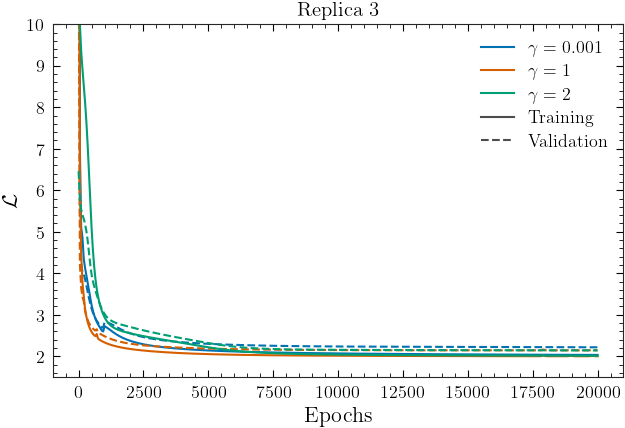

In [12]:
# Overlay the selected replica: one colour per fit, solid = train, dashed = val.
fig, ax = make_figure()
handles, labels = [], []

for fit, color, label in zip(FITS[:3], OKABE_ITO[:3], LABELS[:3]):
    tr_grid, vl_grid = grids[fit]
    # get_plotting_data takes a 0-based row; REPLICA is the 1-based id.
    tr_stats = tr_grid.get_plotting_data(replica_idx=REPLICA - 1)
    vl_stats = vl_grid.get_plotting_data(replica_idx=REPLICA - 1)

    h = draw_line(ax, tr_stats, tr_grid.xgrid, color=color, linestyle="-")
    draw_line(ax, vl_stats, vl_grid.xgrid, color=color, linestyle="--")
    handles.append(h)               # one legend entry (colour) per fit
    labels.append(label)

# Linestyle key: solid = training, dashed = validation (colour-agnostic, grey).
handles += [HandlerSpec("0.3", None, "-", draw_box=False), HandlerSpec("0.3", None, "--", draw_box=False)]
labels += [r"$\rm Training$", r"$\rm Validation$"]

ax.set_xscale(XSCALE)
# ax.set_yscale(YSCALE)
ax.set_xlabel(grids[FITS[0]][0].xlabel)
ax.set_ylabel(r"$\mathcal{L}$")
ax.set_title(rf"$\rm Replica\ {REPLICA}$")
ax.legend(handles=handles, labels=labels, handler_map={HandlerSpec: LineHandler()})
ax.set_ylim(1.5, 10)
display(fig)
fig.savefig("loss_study_small_gamma.pdf", bbox_inches="tight", dpi=300)